In [7]:
import sqlite3

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DB_PATH = "../../CCSMLDatabase.db"
TABLE = "master_nodimer"

conn = sqlite3.connect(DB_PATH)
df = pd.read_sql_query(
    f"SELECT smi, adduct, ccs, superclass, class, subclass FROM master_nodimer WHERE smi IS NOT NULL",
    conn,
)
conn.close()

# Global style settings
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"], # Standard crisp fonts
    "axes.linewidth": 1.5,               # Thicker axis lines
    "axes.spines.top": False,            # Remove top spine
    "axes.spines.right": False,          # Remove right spine
    "xtick.major.width": 1.5,            # Match tick thickness to axis
    "ytick.major.width": 1.5,
    "xtick.direction": "out",            # Ticks point outside
    "ytick.direction": "out",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.labelweight": "normal",
})

n = df.shape[0]
df.columns

Index(['smi', 'adduct', 'ccs', 'superclass', 'class', 'subclass'], dtype='object')

# R2-#2: full distribution of replicate CCS deviation (pre-filtering, master_nodimer)

Same per-point metric `clean()` uses to filter outliers: percent deviation from each `(smi, adduct)` group's median CCS. Restricted to groups with >=2 measurements -- a group of 1 has no replicate variance to report.

In [9]:
CCS_OUTLIER_THRESHOLD_PCT = 1.0  # must match data.py's clean()

grouped_ccs = df.groupby(["smi", "adduct"])["ccs"]
group_size = grouped_ccs.transform("size")
group_median_ccs = grouped_ccs.transform("median")

df["deviation_pct"] = (df["ccs"] - group_median_ccs).abs() / group_median_ccs * 100

replicate_df = df[group_size >= 2]
n_measurements = len(replicate_df)
n_groups = replicate_df.groupby(["smi", "adduct"]).ngroups

print(f"Replicate measurements: {n_measurements} across {n_groups} (smi, adduct) groups")
print(f"Median deviation: {replicate_df['deviation_pct'].median():.3f}%")
print(f"Mean deviation: {replicate_df['deviation_pct'].mean():.3f}%")
print(
    f"Measurements beyond the {CCS_OUTLIER_THRESHOLD_PCT}% threshold: "
    f"{(replicate_df['deviation_pct'] > CCS_OUTLIER_THRESHOLD_PCT).mean() * 100:.1f}%"
)

Replicate measurements: 9294 across 3614 (smi, adduct) groups
Median deviation: 0.340%
Mean deviation: 0.842%
Measurements beyond the 1.0% threshold: 23.9%


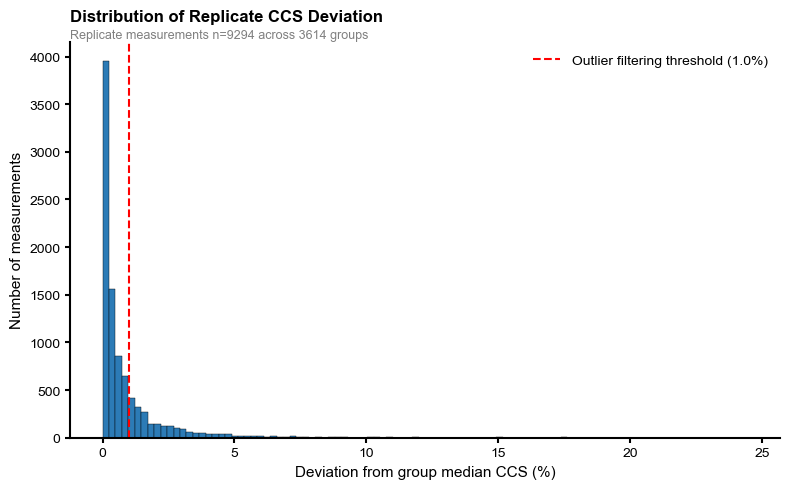

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(replicate_df["deviation_pct"], bins=100, color="#2c7bb6", edgecolor="black", linewidth=0.3)
ax.axvline(
    CCS_OUTLIER_THRESHOLD_PCT, color="red", linestyle="--", linewidth=1.5,
    label=f"Outlier filtering threshold ({CCS_OUTLIER_THRESHOLD_PCT}%)",
)
ax.legend(frameon=False)

ax.set_xlabel("Deviation from group median CCS (%)")
ax.set_ylabel("Number of measurements")
ax.set_title("Distribution of Replicate CCS Deviation", loc="left", fontweight="bold", pad=15)
ax.text(0, 1.01, f"Replicate measurements n={n_measurements} across {n_groups} groups",
        transform=ax.transAxes, fontsize=9, color="gray")

plt.tight_layout()
plt.show()

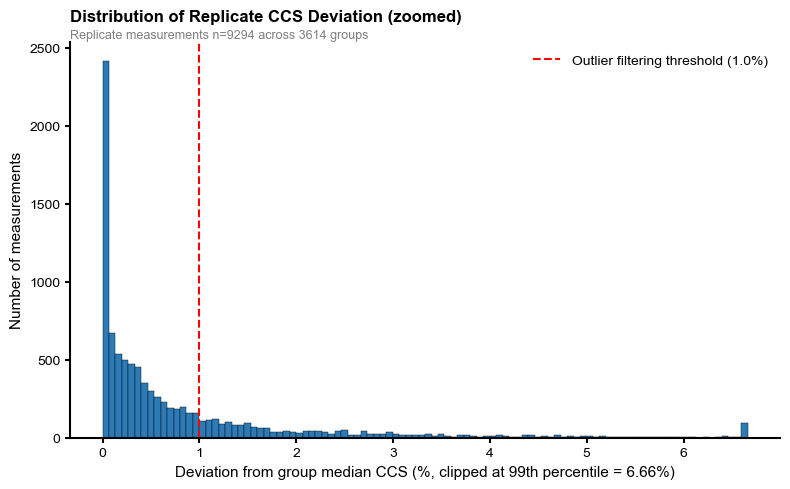

In [11]:
# same distribution, x-axis clipped to the 99th percentile -- the raw histogram above
# is typically dominated by a long tail from a small number of highly discordant groups
clip = replicate_df["deviation_pct"].quantile(0.99)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(replicate_df["deviation_pct"].clip(upper=clip), bins=100, color="#2c7bb6", edgecolor="black", linewidth=0.3)
ax.axvline(
    CCS_OUTLIER_THRESHOLD_PCT, color="red", linestyle="--", linewidth=1.5,
    label=f"Outlier filtering threshold ({CCS_OUTLIER_THRESHOLD_PCT}%)",
)
ax.legend(frameon=False)

ax.set_xlabel(f"Deviation from group median CCS (%, clipped at 99th percentile = {clip:.2f}%)")
ax.set_ylabel("Number of measurements")
ax.set_title("Distribution of Replicate CCS Deviation (zoomed)", loc="left", fontweight="bold", pad=15)
ax.text(0, 1.01, f"Replicate measurements n={n_measurements} across {n_groups} groups",
        transform=ax.transAxes, fontsize=9, color="gray")

plt.tight_layout()
plt.show()

# R2-#1: is there a class or substructure trend among the compounds removed by outlier filtering?

Reproduces `clean()`'s exact `keep_mask` logic (not just the deviation_pct threshold above -- small groups use a whole-group max/min ratio instead of per-point deviation) to know precisely which measurements would be dropped.

In [12]:
within_threshold = df["deviation_pct"] <= CCS_OUTLIER_THRESHOLD_PCT
group_has_survivor = within_threshold.groupby([df["smi"], df["adduct"]]).transform("any")
is_closest_to_median = df["deviation_pct"] == df.groupby(["smi", "adduct"])["deviation_pct"].transform("min")
per_point_keep = within_threshold | (~group_has_survivor & is_closest_to_median)

group_max_min_ratio = grouped_ccs.transform(lambda x: x.max() / x.min())
whole_group_keep = group_max_min_ratio <= 1 + CCS_OUTLIER_THRESHOLD_PCT / 100

keep_mask = whole_group_keep.where(group_size < 3, per_point_keep)
removed_df = df[~keep_mask]

print(f"Removed measurements: {len(removed_df)} / {len(df)} ({len(removed_df) / len(df) * 100:.1f}%)")

Removed measurements: 2903 / 69556 (4.2%)


## Class trend

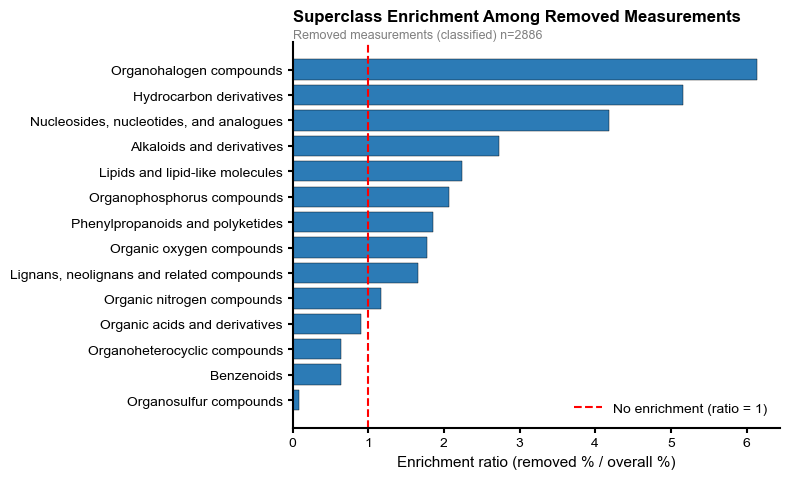

Chi-square goodness-of-fit: chi2=1426.94, p=2.12e-291


In [13]:
from scipy.stats import chisquare

classified_df = df[df["superclass"].notna()]
classified_removed_df = removed_df[removed_df["superclass"].notna()]

removed_superclass_pct = classified_removed_df["superclass"].value_counts(normalize=True)
overall_superclass_pct = classified_df["superclass"].value_counts(normalize=True)

enrichment = (removed_superclass_pct / overall_superclass_pct).dropna().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(enrichment))))
ax.barh(enrichment.index, enrichment.values, color="#2c7bb6", edgecolor="black", linewidth=0.3)
ax.axvline(1.0, color="red", linestyle="--", linewidth=1.5, label="No enrichment (ratio = 1)")
ax.legend(frameon=False, loc="lower right")

ax.set_xlabel("Enrichment ratio (removed % / overall %)")
ax.set_title("Superclass Enrichment Among Removed Measurements", loc="left", fontweight="bold", pad=15)
ax.text(0, 1.01, f"Removed measurements (classified) n={len(classified_removed_df)}",
        transform=ax.transAxes, fontsize=9, color="gray")

plt.tight_layout()
plt.show()

# chi-square goodness-of-fit: does the removed set's class distribution match what
# you'd expect if removal were independent of class (i.e. sampled at the overall rate)?
categories = overall_superclass_pct.index
observed = classified_removed_df["superclass"].value_counts().reindex(categories, fill_value=0)
expected = overall_superclass_pct.reindex(categories) * len(classified_removed_df)
chi2, p_value = chisquare(observed, expected)
print(f"Chi-square goodness-of-fit: chi2={chi2:.2f}, p={p_value:.2e}")

## Substructure trend

A molecule counts as "high-variance" if any of its measurements were removed. Fingerprint vocabulary and Fisher's exact enrichment test run at the molecule level (fingerprints don't vary by adduct), comparing each substructure's presence rate in the high-variance set against the rest of the dataset.

In [14]:
import sys
import os

sys.path.append(os.path.abspath("../.."))

from training_utils import calculate_sparse_fingerprints, build_fingerprint_vocabulary

molecule_df = df.drop_duplicates(subset=["smi"], keep="first").reset_index(drop=True)
high_variance_smi = set(removed_df["smi"].unique())
is_high_variance = molecule_df["smi"].isin(high_variance_smi).to_numpy()

print(f"Unique molecules: {len(molecule_df)} | High-variance: {is_high_variance.sum()} ({is_high_variance.mean() * 100:.1f}%)")

fps = calculate_sparse_fingerprints(molecule_df["smi"])
fp_vocab = build_fingerprint_vocabulary(fps, min_molecule_count=10)
print(f"Fingerprint vocabulary: {len(fp_vocab)} substructures kept (min_count=10)")

Unique molecules: 31454 | High-variance: 1272 (4.0%)
Fingerprint vocabulary: 8165 substructures kept (min_count=10)


In [15]:
from scipy.stats import fisher_exact

n_high_variance = int(is_high_variance.sum())
n_background = len(molecule_df) - n_high_variance

presence_matrix = {env_id: set() for env_id in fp_vocab}
for i, fp in enumerate(fps):
    for env_id in fp:
        if env_id in presence_matrix:
            presence_matrix[env_id].add(i)

results = []
for env_id, mol_indices in presence_matrix.items():
    present_mask = np.zeros(len(molecule_df), dtype=bool)
    present_mask[np.fromiter(mol_indices, dtype=int)] = True

    a = int((present_mask & is_high_variance).sum())
    b = int((present_mask & ~is_high_variance).sum())
    c = n_high_variance - a
    d = n_background - b

    odds_ratio, p_value = fisher_exact([[a, b], [c, d]], alternative="greater")
    results.append((
        env_id, a, b, a / n_high_variance, b / n_background, odds_ratio, p_value, mol_indices
    ))

results_df = pd.DataFrame(results, columns=[
    "env_id", "count_high_variance", "count_background",
    "rate_high_variance", "rate_background", "odds_ratio", "p_value", "molecule_indices",
])
results_df = results_df.sort_values("p_value").reset_index(drop=True)
results_df.drop(columns=["molecule_indices"]).head(15)

,env_id,count_high_variance,count_background,rate_high_variance,rate_background,odds_ratio,p_value
0,864662311,819,4622,0.643868,0.153138,9.998080,1.235164e-322
1,3072032085,819,4622,0.643868,0.153138,9.998080,1.235164e-322
2,127271038,295,1373,0.231918,0.045491,6.335561,3.625028e-110
3,1740830013,235,1030,0.184748,0.034126,6.413871,6.933781e-91
4,980906191,183,967,0.143868,0.032039,5.076947,4.376417e-59
5,4156912708,146,658,0.114780,0.021801,5.817867,3.026097e-54
6,2928264258,146,658,0.114780,0.021801,5.817867,3.026097e-54
7,3021694889,258,2024,0.202830,0.067060,3.539754,1.173427e-53
8,847957139,258,2024,0.202830,0.067060,3.539754,1.173427e-53
9,4047067920,97,279,0.076258,0.009244,8.847986,3.966636e-50


In [16]:
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator

morgan_generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, includeChirality=True)


def depict_substructure(env_id, molecule_indices):
    # prefer depicting from a molecule actually in the high-variance set, since
    # that's the population the enrichment claim is about
    ordered_indices = sorted(molecule_indices, key=lambda idx: not is_high_variance[idx])
    for mol_idx in ordered_indices:
        mol = Chem.MolFromSmiles(molecule_df["smi"].iloc[mol_idx])
        mol = Chem.AddHs(mol)

        ao = rdFingerprintGenerator.AdditionalOutput()
        ao.AllocateBitInfoMap()
        morgan_generator.GetSparseCountFingerprint(mol, additionalOutput=ao)
        bit_info = ao.GetBitInfoMap()
        if env_id not in bit_info:
            continue

        atom_idx, radius = bit_info[env_id][0]
        if radius == 0:
            return Chem.MolFragmentToSmiles(mol, atomsToUse=[atom_idx])
        env_bonds = Chem.FindAtomEnvironmentOfRadiusN(mol, radius, atom_idx)
        submol = Chem.PathToSubmol(mol, env_bonds)
        return Chem.MolToSmiles(submol)
    return None


top_hits = results_df.head(15).copy()
top_hits["substructure_smiles"] = [
    depict_substructure(row.env_id, row.molecule_indices) for row in top_hits.itertuples()
]
top_hits_display = top_hits.drop(columns=["molecule_indices"])
top_hits_display

,env_id,count_high_variance,count_background,rate_high_variance,rate_background,odds_ratio,p_value,substructure_smiles
0,864662311,819,4622,0.643868,0.153138,9.998080,1.235164e-322,O
1,3072032085,819,4622,0.643868,0.153138,9.998080,1.235164e-322,[H]O
2,127271038,295,1373,0.231918,0.045491,6.335561,3.625028e-110,CO
3,1740830013,235,1030,0.184748,0.034126,6.413871,6.933781e-91,CO
4,980906191,183,967,0.143868,0.032039,5.076947,4.376417e-59,CO
5,4156912708,146,658,0.114780,0.021801,5.817867,3.026097e-54,CC(C)O
6,2928264258,146,658,0.114780,0.021801,5.817867,3.026097e-54,CC(C)O
7,3021694889,258,2024,0.202830,0.067060,3.539754,1.173427e-53,[H]N
8,847957139,258,2024,0.202830,0.067060,3.539754,1.173427e-53,N
9,4047067920,97,279,0.076258,0.009244,8.847986,3.966636e-50,CC(C)O


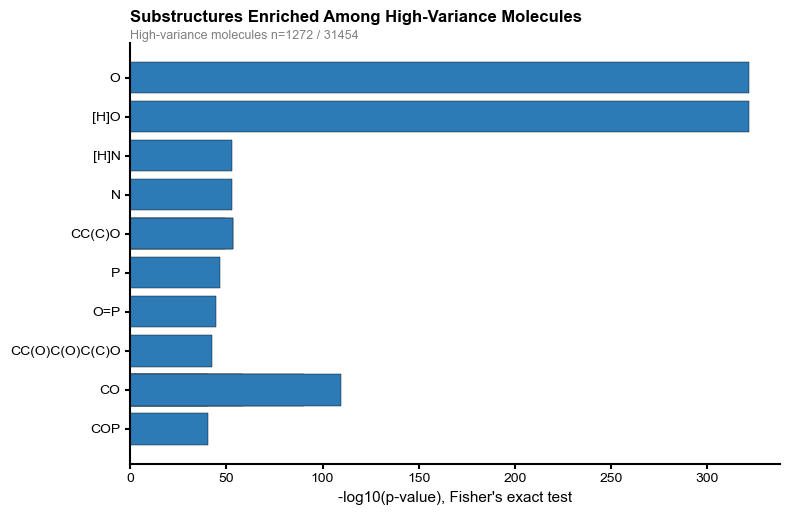

In [17]:
plot_hits = top_hits.iloc[::-1]
labels = [s if s else f"env_id={eid}" for s, eid in zip(plot_hits["substructure_smiles"], plot_hits["env_id"])]

fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(plot_hits))))
ax.barh(labels, -np.log10(plot_hits["p_value"]), color="#2c7bb6", edgecolor="black", linewidth=0.3)

ax.set_xlabel("-log10(p-value), Fisher's exact test")
ax.set_title("Substructures Enriched Among High-Variance Molecules", loc="left", fontweight="bold", pad=15)
ax.text(0, 1.01, f"High-variance molecules n={n_high_variance} / {len(molecule_df)}",
        transform=ax.transAxes, fontsize=9, color="gray")

plt.tight_layout()
plt.show()